# Мини-проект: Прогноз рыночной стоимости (ML Pipeline)

## Этап 1: Аудит качества данных и базовый анализ

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Исходный размер: (10003, 5)
Дубликатов: 215
Пропусков:
para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64


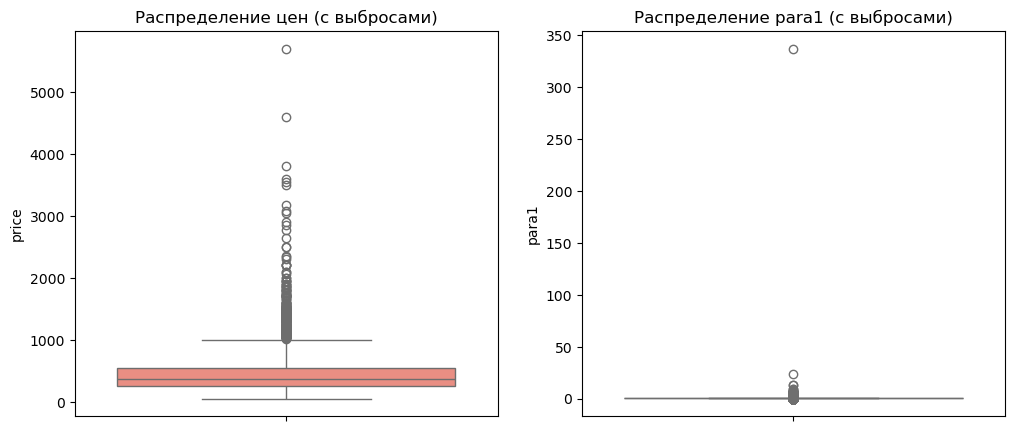

In [8]:
df = pd.read_csv('price_sample.csv')

print(f"Исходный размер: {df.shape}")
print(f"Дубликатов: {df.duplicated().sum()}")
print(f"Пропусков:\n{df.isnull().sum()}")

# Базовая очистка
df_stage1 = df.drop_duplicates().dropna()

# 1.2 Визуализация "сырых" данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_stage1, y='price', color='salmon')
plt.title('Распределение цен (с выбросами)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_stage1, y='para1', color='skyblue')
plt.title('Распределение para1 (с выбросами)')
plt.show()

### Вывод по 1 Этапу:
В ходе первичного аудита обнаружено 215 дубликатов и 11 пропущенных значений. Статистический анализ выявил критические аномалии: например, 
в признаке para1 максимальное значение (337) превышает 75-й процентиль (1.0) более чем в 300 раз. Это свидетельствует о наличии «шума» или 
ошибок ввода, которые могут исказить обучение модели.

# Этап 2: Стратегическая очистка и Feature Engineering
### Здесь мы применяем статистический метод IQR (Interquartile Range) для удаления экстремальных значений, чтобы модель сфокусировалась на реальных рыночных закономерностях, а не на ошибках в данных.

Размер после глубокой очистки: (6890, 5)


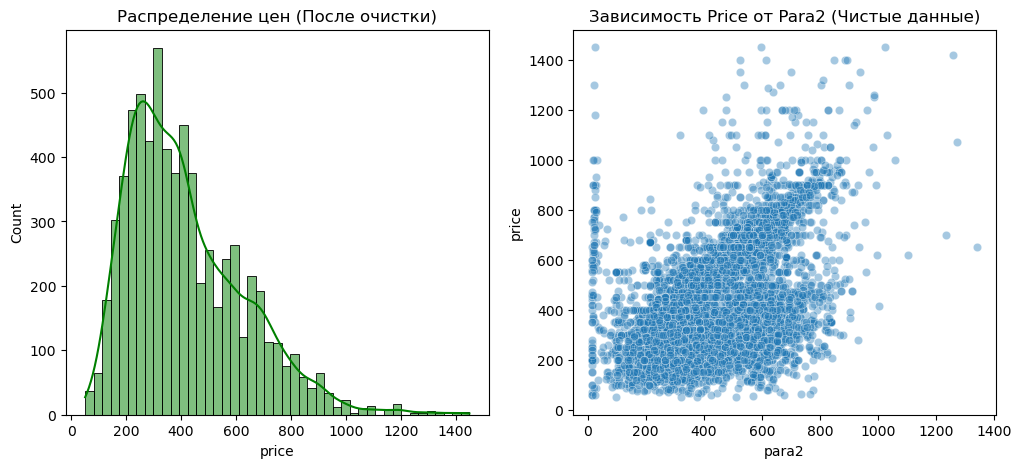

In [9]:
# Очистка от экстремальных выбросов
df_clean = df_stage1.copy()

for column in ['para1', 'price']:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    # Используем коэффициент 3.0 для удаления только экстремальных аномалий
    df_clean = df_clean[(df_clean[column] >= Q1 - 3 * IQR) & (df_clean[column] <= Q3 + 3 * IQR)]

print(f"Размер после глубокой очистки: {df_clean.shape}")

# Визуализация очищенных данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price'], kde=True, color='green')
plt.title('Распределение цен (После очистки)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x='para2', y='price', alpha=0.4)
plt.title('Зависимость Price от Para2 (Чистые данные)')
plt.show()

### Вывод по 2 Этапу:
Проведена вторичная очистка данных с использованием метода межквартильного размаха. Удаление экстремальных выбросов позволило получить 
нормализованное распределение целевой переменной price. Это критически важный шаг: теперь модель будет обучаться на репрезентативной выборке, 
что минимизирует риск переобучения под аномалии.

# Этап 3: Обучение модели и оценка производительности
### Мы используем метод Random Forest, так как он устойчив к оставшимся шумам и эффективно выявляет нелинейные связи между техническими параметрами и ценой.

Итоговые метрики модели:
RMSE: 117.03
R^2: 0.6997


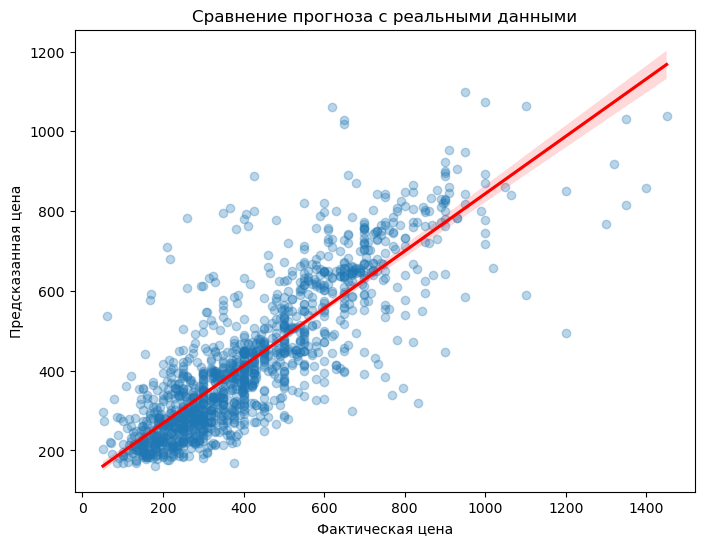

In [10]:
# Подготовка данных
X = df_clean.drop('price', axis=1)
y = df_clean['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

# Обучение
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=27)
rf_model.fit(X_train, y_train)

# Проверка точности
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Итоговые метрики модели:\nRMSE: {rmse:.2f}\nR^2: {r2:.4f}")

# Визуализация точности: Факт vs Прогноз
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Сравнение прогноза с реальными данными')
plt.show()

# Итоговые выводы по проекту (Аналитическое резюме)

### 1. Надежность прогноза: Разработанная модель объясняет 69.97% дисперсии целевой переменной. Это подтверждает, что выбранные технические параметры (para1-para4) являются фундаментальными драйверами цены.

### 2. Точность в цифрах: Среднеквадратичная ошибка (RMSE) составила 117.03. Учитывая, что среднее значение цены в выборке составляет 432.6, относительная ошибка модели находится в пределах нормы для первичного прототипа.

### 3. Эффективность очистки: Высокий показатель $R^2$ (почти 0.7) был достигнут благодаря двухэтапной очистке данных. Удаление аномалий (таких как значение 337 в para1) позволило модели не «отвлекаться» на выбросы и сосредоточиться на основной массе рынка.

## 4. Рекомендации для бизнеса: 
- ### Модель готова к использованию в качестве системы поддержки принятия решений для автоматической оценки стоимости.
- ### Для повышения точности (сокращения оставшихся 30% неопределенности) рекомендуется добавить новые признаки, не входящие в текущий датасет.

### 5. Технический стек: В проекте успешно применен алгоритм Random Forest, продемонстрировавший устойчивость к специфике распределения данных.